### prompt chaining : multiple time calling llm

#### topic -> blog generation

##### topic -> detailed outline -> llm (topic + detailed outline generate a blog)

##### Start -> generate outline -> generate blog -> END

In [2]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict

In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
# create state
class BLOGState(TypedDict):
    title : str
    outline : str
    content : str

In [6]:
def create_outline(state : BLOGState) -> BLOGState:

    # title
    title = state['title']

    # call llm
    prompt = f"generate a outline for a blog on topic - {title}"
    outline = model.invoke(prompt).content

    # update State
    state['outline'] = outline

    
    return state

In [7]:
def create_blog(state : BLOGState) -> BLOGState:

    title = state['title']
    outline = state['outline']

    prompt = f"write a detailed blog on the {title} using the following outline \n {outline}"

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [8]:
# define graph
graph = StateGraph(BLOGState)

# create Node
graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)

# create edge
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

# compile graph
workflow = graph.compile()


In [9]:
initial_state = {"title":"Rise of AI in INDIA"}

# execute graph
final_state =  workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in INDIA', 'outline': 'Here\'s a suggested outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Context: India\'s emergence as a significant player in the global AI landscape\n* Thesis statement: India is witnessing a significant rise in AI adoption and development, driven by government initiatives, technological advancements, and a growing talent pool.\n\n**II. Current State of AI in India**\n\n* Overview of India\'s AI ecosystem: startups, research institutions, and industry players\n* Key sectors where AI is being adopted: healthcare, finance, education, transportation, etc.\n* Statistics and trends: investments, funding, job creation, and AI-related research papers published\n\n**III. Government Initiatives and Policies**\n\n* Overview of government initiatives: Digital India, Make in India, Startup India, and AI-related policies\n* National AI S

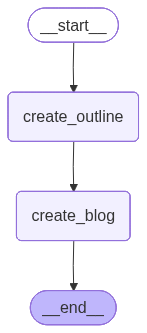

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
print(final_state['outline'])

Here's a suggested outline for a blog on the topic "Rise of AI in India":

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance globally
* Context: India's emergence as a significant player in the global AI landscape
* Thesis statement: India is witnessing a significant rise in AI adoption and development, driven by government initiatives, technological advancements, and a growing talent pool.

**II. Current State of AI in India**

* Overview of India's AI ecosystem: startups, research institutions, and industry players
* Key sectors where AI is being adopted: healthcare, finance, education, transportation, etc.
* Statistics and trends: investments, funding, job creation, and AI-related research papers published

**III. Government Initiatives and Policies**

* Overview of government initiatives: Digital India, Make in India, Startup India, and AI-related policies
* National AI Strategy: goals, objectives, and key areas of focus (e.g., healthc

In [12]:
print(final_state['content'])

**The Rise of AI in India: A New Era of Innovation and Growth**

**Introduction**

Artificial Intelligence (AI) has been transforming the world at an unprecedented pace, and India has emerged as a significant player in the global AI landscape. With its vast pool of skilled professionals, favorable business environment, and government support, India is witnessing a significant rise in AI adoption and development. In this blog, we will explore the current state of AI in India, government initiatives, key drivers of AI adoption, applications, challenges, and future outlook.

**Current State of AI in India**

India's AI ecosystem is thriving, with numerous startups, research institutions, and industry players actively involved in AI development and deployment. The country has seen a significant increase in AI-related investments, funding, and job creation. According to a report by Nasscom, the Indian AI market is expected to reach $7.8 billion by 2025, growing at a CAGR of 30.8%. The key s

In [13]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict

In [14]:
load_dotenv()

True

In [15]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [16]:
class BLOGStates(TypedDict):
    title : str
    outline : str
    content : str
    mark : int

In [17]:
def create_outline(state : BLOGStates) -> BLOGStates:

    # title
    title = state['title']

    # call llm
    prompt = f"generate a outline for a blog on topic - {title}"
    outline = model.invoke(prompt).content

    # update State
    state['outline'] = outline

    
    return state

In [18]:
def create_blog(state : BLOGStates) -> BLOGStates:

    title = state['title']
    outline = state['outline']

    prompt = f"write a detailed blog on the {title} using the following outline \n {outline}"

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [19]:
def evaluate_blog(state: BLOGStates) -> BLOGStates:
    title = state['title']
    outline = state['outline']
    content = state['content']
    
    prompt = f"Based on this outline:\n{outline}\n\nRate the following blog:\n{content}\n\n Strictly : Return an integer score."

    mark = model.invoke(prompt).content

    state['mark'] = mark

    return state

In [20]:
# initialize graph 
graph1 = StateGraph(BLOGStates)

# create node
graph1.add_node('create_outline',create_outline)
graph1.add_node('create_blog',create_blog)
graph1.add_node('evaluate_blog',evaluate_blog)

# create edge
graph1.add_edge(START,'create_outline')
graph1.add_edge('create_outline','create_blog')
graph1.add_edge('create_blog','evaluate_blog')
graph1.add_edge('evaluate_blog',END)


# graph compile
workflow = graph1.compile()

In [21]:
initial_state = {"title":"Rise of AI in INDIA"}

# execute graph
final_state =  workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in INDIA', 'outline': 'Here\'s a suggested outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Context: India\'s emergence as a significant player in the global AI landscape\n* Thesis statement: India is witnessing a significant rise in AI adoption, driven by government initiatives, technological advancements, and innovative startups.\n\n**II. Current State of AI in India**\n\n* Overview of India\'s AI ecosystem, including key industries, startups, and research institutions\n* Discussion of the current AI landscape in India, including areas of focus (e.g., natural language processing, computer vision, robotics)\n* Statistics on AI adoption, investment, and job creation in India\n\n**III. Government Initiatives and Support**\n\n* Discussion of government initiatives to promote AI adoption, such as:\n\t+ National AI Strategy (2018)\n\t+ establishment 

In [22]:
print(final_state['mark'])

I would rate this blog an 8 out of 10. 

The blog is well-structured, easy to follow, and provides a comprehensive overview of the rise of AI in India. It covers the current state of AI in India, government initiatives, key industries driving adoption, startups, and innovation, as well as the challenges and opportunities that lie ahead. The blog also provides specific examples and statistics to support its claims, making it a credible and informative read.

However, there are a few areas where the blog could be improved. For example, some of the sections could be more detailed and provide more in-depth analysis, and the blog could benefit from more visual elements, such as images or infographics, to break up the text and make it more engaging. Additionally, the blog could provide more concrete recommendations for how India can address the challenges facing its AI ecosystem and drive growth and innovation in the sector. 

Overall, the blog is well-written and provides a thorough overvie

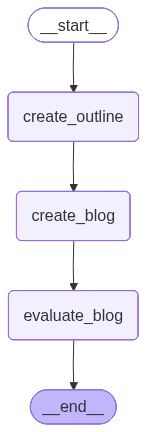

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())